In [14]:
import numpy as np
import matplotlib.pyplot as plt
import bionetgen
import roadrunner

# Load model from BNGL
infile="RasModel.bngl"
result = bionetgen.run(infile)

BioNetGen version 2.9.3
Reading from file /Users/faeder/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Projects/SIAMLS26/notebooks/RasModel.bngl (level 0)
Read 5 parameters.
Read 1 species.
Read 2 observable(s).
Read 4 reaction rule(s).
ACTION: simulate( method=>"ssa" )
ACTION: generate_network( RasModel )
Iteration   0:     1 species      0 rxns  0.00e+00 CPU s
Iteration   1:     2 species      1 rxns  0.00e+00 CPU s
Iteration   2:     3 species      3 rxns  0.00e+00 CPU s
Iteration   3:     3 species      4 rxns  0.00e+00 CPU s
Cumulative CPU time for each rule
Rule   1:     1 reactions 0.00e+00 CPU s 0.00e+00 CPU s/rxn
Rule   2:     1 reactions 0.00e+00 CPU s 0.00e+00 CPU s/rxn
Rule   3:     1 reactions 0.00e+00 CPU s 0.00e+00 CPU s/rxn
Rule   4:     1 reactions 0.00e+00 CPU s 0.00e+00 CPU s/rxn
Total   :     4 reactions 0.00e+00 CPU s 0.00e+00 CPU s/rxn
Wrote network in net format to ./RasModel.net.
TSTART:0
TEND:10000
Network simulation using ssa
Wrote network in net format 

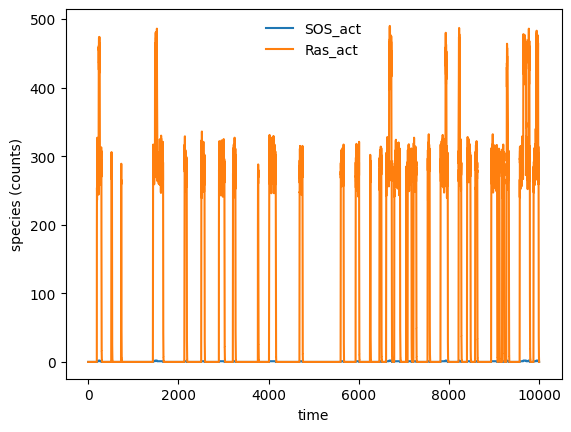

In [15]:
r = result[0]
for name in r.dtype.names:
    if name != "time":
        plt.plot(r['time'], r[name], label = name)
plt.xlabel("time")
plt.ylabel("species (counts)")
_ = plt.legend(frameon = False)

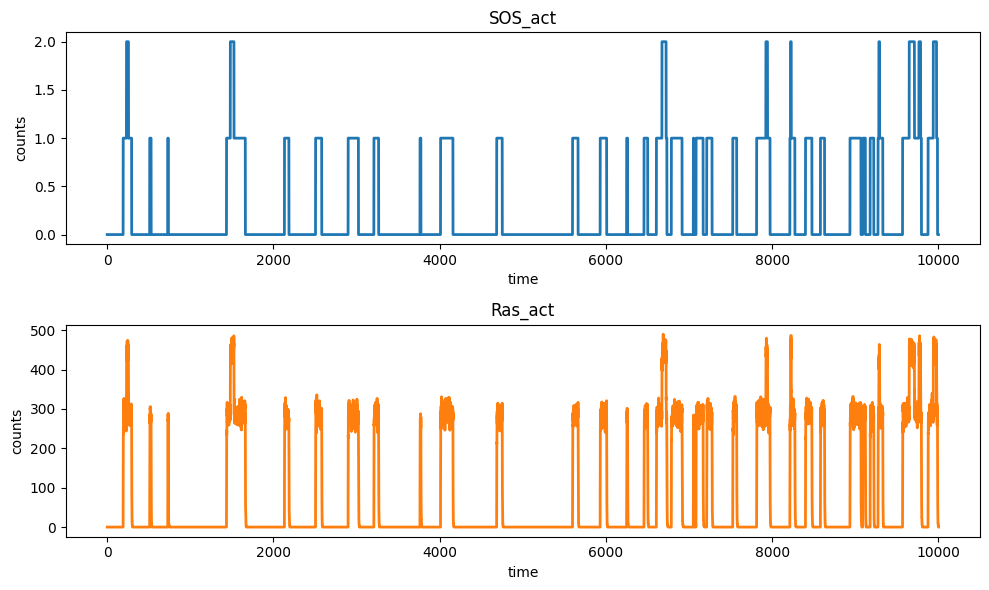

In [16]:
# Get the observable names (excluding 'time')
observables = [name for name in r.dtype.names if name != "time"]
n_observables = len(observables)

# Create subplots with one row per observable
fig, axes = plt.subplots(n_observables, 1, figsize=(10, 3*n_observables))
# Grabs the exact list of default colors (up to 10)
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [default_colors[i % len(default_colors)] for i in range(n_observables)]

# Plot each observable in a separate row
for i, obs_name in enumerate(observables):
    axes[i].plot(r['time'], r[obs_name], label=obs_name, color=colors[i], linewidth=2)
    axes[i].set_xlabel("time")
    axes[i].set_ylabel("counts")
    #axes[i].legend(frameon=False)
    axes[i].set_title(obs_name)
plt.tight_layout()

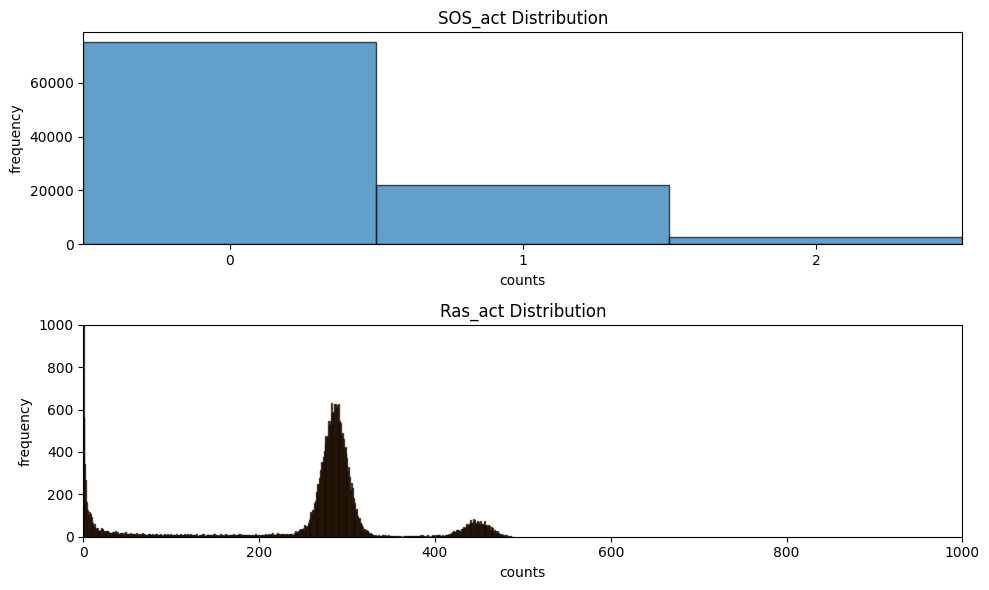

In [22]:
# Create histograms for each observable
fig_hist, axes_hist = plt.subplots(n_observables, 1, figsize=(10, 3*n_observables))

for i, obs_name in enumerate(observables):
    data = r[obs_name]
    min_val, max_val = np.nanmin(data), np.nanmax(data)
    min_int, max_int = int(np.floor(min_val)), int(np.ceil(max_val))
    centers = np.arange(min_int, max_int + 1)
    # edges such that bin centers fall on integer values
    edges = np.concatenate((centers - 0.5, [centers[-1] + 0.5]))
    axes_hist[i].clear()
    axes_hist[i].hist(data, bins=edges, color=colors[i], alpha=0.7, edgecolor='black')
    axes_hist[i].set_xlabel("counts")
    axes_hist[i].set_ylabel("frequency")
    axes_hist[i].set_title(f"{obs_name} Distribution")
    if len(centers) < 20:
        axes_hist[i].set_xticks(centers)
    axes_hist[i].set_xlim(edges[0], edges[-1])
    # set y-axis limits to see secondary peaks
    if (i==1):
       axes_hist[i].set_xlim(0, 1000)
       axes_hist[i].set_ylim(0, 1000)
    # set y-axis to log scale
    # axes_hist[i].set_yscale('log')

plt.tight_layout()